# **Equazioni Differenziali Ordinarie (ODE) - Parte 1: metodi di Eulero**
Consideriamo l'evoluzione temporale di una quantità scalare $y=y(t)\in\mathbb{R}$, la cui dinamica è descritta da un problema di Cauchy della forma:
\begin{equation*}
\begin{cases}
y'(t)=f(t,y(t)) & t_0 \le t\le t_{N},\\ y(0)=y_{0}.
\end{cases}
\end{equation*}
</br>
Per poter risolvere numericamente il problema suddividiamo l'intervallo $I=[t_0,t_N]$ in $N$ sottointervalli con la stessa dimensione data da
</br></br>
\begin{equation*}
h= \dfrac{t_N-t_0}{N}
\end{equation*}
</br>
e definiamo gli istanti discreti $\{t_{0},t_{1},\dots,t_{N}\}$ in cui calcoleremo la soluzione approssimata come
</br></br>
\begin{equation*}
t_n=t_0+nh.
\end{equation*}
</br>
Lo scopo di un metodo numerico per l'equazioni differenziali ordinarie (ODE)  è quello di approssimare la dinamica di $y$ con una sequenza discreta 
$\{u_{0}=y_{0},u_{1},\dots,u_{N}\}$
tale per cui
\begin{equation*}
u_{n}\approx y(t_{n}).
\end{equation*}

## 1. Il metodo di Eulero in avanti </br>
L'idea del metodo di Eulero in avanti è quella di costruire una griglia temporale equispaziata di passo $h>0$ ed approssimare la soluzione del sistema secondo lo schema iterativo sottostante
</br> </br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+hf(t_{n},u_{n}) & n=0,\dots,N-1
\end{cases}
\end{equation*}
</br>
Tale schema è detto *esplicito* e ad un passo (*one-step*), in quanto, ad ogni passo temporale, la soluzione numerica $u_{n+1}$ dipende soltanto dalla soluzione al passo temporale precedente $u_{n}$.

<mark>**Esercizio 1**</mark></br></br>
Scrivere una funzione chiamata $\texttt{eulero\_avanti}$ che, dati $f$, $t_0$, $t_N$, $y_0$ ed $h$, implementi il metodo di Eulero in avanti, restituendo la griglia temporale $\mathbf{t}_h=[t_{0},\dots,t_{N}]$ e la sequenza approssimante $\mathbf{u}_h=[u_{0},\dots,u_{N}]$.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def eulero_avanti(f, t0, tN, y0, h):
    """Metodo di Eulero in avanti
    Input:
        f   (lambda function)               Funzione che rappresenta il termine di destra dell'ODE: f(t, y)                    
        t0  (float)                         Tempo iniziale
        tN  (float)                         Tempo finale
        y0  (float,list o numpy.ndarray)    Condizione iniziale: scalare.
        h   (float)                         Passo temporale

    Output:
        t_h   (numpy.ndarray)     Vettore degli istanti temporali (lunghezza N+1).
        u_h   (numpy.ndarray)     Soluzione discreta nei nodi temporali (lunghezza N+1).
    """

    # Determiniamo il numero di passi N
    N = int((tN - t0) / h)

    # inizializzazione vettiri t_h e u_h
    u_h = np.zeros(N+1)
    t_h = np.zeros(N+1)   
    
    u_h[0] = y0
    t_h[0] = t0

    # Implementazione del metodo di Eulero in avanti e di t
    for i in range(N):
        u_h[i+1] = u_h[i] + h * f(t_h[i], u_h[i])
        t_h[i+1] = t_h[i] + h

    return t_h, u_h

## 2. Il metodo di Eulero all'indietro </br>
In alternativa al metodo di Eulero "in avanti", esiste anche una sua versione "all'indietro", la quale si basa invece sul seguente schema iterativo
</br></br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+hf(t_{n+1},u_{n+1}) & n=0,\dots,N-1
\end{cases}
\end{equation*}
</br>
Tale schema è detto *implicito* e ad un passo (*one-step*), in quanto, ad ogni passo temporale, la soluzione numerica $u_{n+1}$ dipende dalla stessa incongita $u_{n+1}$, oltre che da $u_n$. Quindi, di volta in volta, bisognerà risolvere un'equazione non lineare
\begin{equation*}
z=u_n + h f(t_{n+1}, z)
\end{equation*}
nella variabile incognita $z$. La soluzione di tale equazione si può approssimare, ad esempio, con il metodo del punto fisso.
</br>
</br>
Si osservi che l'utilizzo di un metodo di punto fisso richiede che il modulo della derivata della funzione di iterazione utilizzata sia minore di uno; questa condizione è generalmente soddisfatta per $h$ sufficientemente piccolo.

<mark>**Esercizio 2**</mark></br></br>
Scrivere una funzione chiamata  $\texttt{eulero\_indietro}$ che, dati $f$, $t_0$, $t_N$, $y_0$ ed $h$, implementi il metodo di Eulero all'indietro, restituendo la griglia temporale $\mathbf{t}_h=[t_{0},\dots,t_{N}]$ e la sequenza approssimante $\mathbf{u}_h=[u_{0},\dots,u_{N}]$. Sfruttare il metodo $\texttt{puntofisso}$ che troviamo in $\texttt{utilis\_ODE.py}$

In [16]:
from utilis_ODE import puntofisso

def eulero_indietro(f, t0, tN, y0, h):
    """Metodo di Eulero all'indietro
    Input:
        f   (lambda function)               Funzione che rappresenta il termine di destra dell'ODE: f(t, y)                    
        t0  (float)                         Tempo iniziale
        tN  (float)                         Tempo finale
        y0  (float,list o numpy.ndarray)    Condizione iniziale: scalare.
        h   (float)                         Passo temporale

    Output:
        t_h   (numpy.ndarray)     Vettore degli istanti temporali (lunghezza N+1).
        u_h   (numpy.ndarray)     Soluzione discreta nei nodi temporali (lunghezza N+1).
    """
    # Determiniamo il numero di passi N
    N = int((tN - t0) / h)

    # inizializzazione la matrice soluzione    
    t_h = np.zeros(N+1)     # abbiamo N passi temporali, quindi N+1 nodi
    u_h = np.zeros(N+1)            

    # ciclo iterativo che calcola i passi di Eulero esplicito
    u_h[0] = y0
    t_h[0] = t0 

    # parametri per il punto fisso
    nmax_pf = 300
    toll_pf = 1e-5

    for i in range(N):
        phi = lambda z: u_h[i] + h * f(t_h[i] + h, z)
        # chiamo il metodo del punto fisso
        u_pf = puntofisso(phi, u_h[i], nmax_pf, toll_pf)
        # carico il vettore u
        u_h[i+1] = u_pf[-1]
        # carico il vettore t
        t_h[i+1] = t_h[i]+h

    return t_h, u_h

## 3. Applicazione a un caso esempio

Si consideri il problema di Cauchy
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0\le t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}
la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}


<mark>**Esercizio 3.1**</mark></br> Rappresentare graficamente la soluzione esatta nell'intervallo considerato.

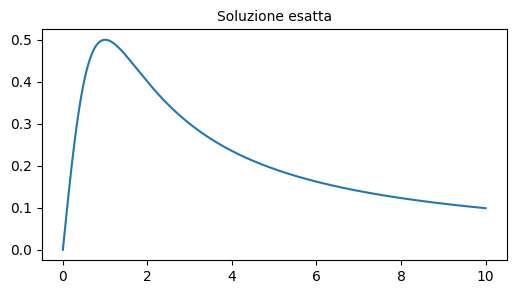

In [17]:
# Es. 3.1 - Plot soluzione esatta
# tempo iniziale e finale
t0, tN = 0, 10
# t per la rappresentazione grafica
tplot = np.linspace(t0, tN, 1000)
# soluzione esatta
yesatta = lambda t: t/(1.0+t**2)

plt.figure(figsize = (6,3))
plt.plot(tplot, yesatta(tplot))
plt.title("Soluzione esatta", fontsize = 10)
plt.show()

<mark>**Esercizio 3.2**</mark></br> Approssimare la soluzione del problema utilizzando il metodo di **Eulero in avanti**, prima con $h=0.2$  e poi con  $h=0.05$. Confrontare graficamente le soluzioni numeriche con la soluzione esatta;

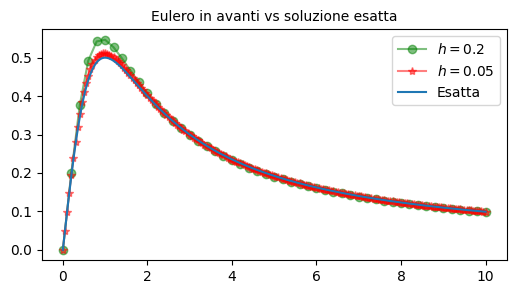

In [18]:
# Es. 3.2 - Eulero in avanti per h = 0.2, 0.05
# dato iniziale
y0 = 0
# funzione f del problema di cauchy che dipende dal tempo e dalla y
f = lambda t, y: 1.0/(1+t**2) - 2*y*y

t1, u1 = eulero_avanti(f, t0, tN, y0, h = 0.2)
t2, u2 = eulero_avanti(f, t0, tN, y0, h = 0.05)

plt.figure(figsize = (6,3))
plt.plot(t1, u1, '-o', label = '$h=0.2$', alpha = 0.5, color = 'green')
plt.plot(t2, u2, '-*', label = '$h=0.05$', alpha = 0.5, color = 'red')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero in avanti vs soluzione esatta", fontsize = 10)
plt.legend()
plt.show()

<mark>**Esercizio 3.3**</mark></br>
Ripetere il l'**Esercizio 3.2** utilizzando il metodo di **Eulero all'indietro**. Come cambiano i risultati?

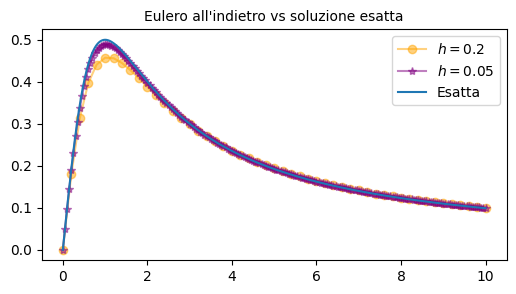

In [19]:
# Es. 3.3 - Eulero all'indietro per h = 0.2, 0.05
# dato iniziale
y0 = 0
# funzione f del problema di cauchy che dipende dal tempo e dalla y
f = lambda t, y: 1.0/(1+t**2) - 2*y*y

t1, u1back = eulero_indietro(f, t0, tN, y0, h = 0.2)
t2, u2back = eulero_indietro(f, t0, tN, y0, h = 0.05)

plt.figure(figsize = (6,3))
plt.plot(t1, u1back, '-o', label = '$h=0.2$', alpha = 0.5, color = 'orange')
plt.plot(t2, u2back, '-*', label = '$h=0.05$', alpha = 0.5, color = 'purple')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero all'indietro vs soluzione esatta", fontsize = 10)
plt.legend()
plt.show()

<mark>**Esercizio 3.4**</mark></br>
I confronti grafici sono molto utili, ma è altrettanto utile avere un riscontro quantitativo. Per valutare la bontà dell'approssimazione $u_n\approx y(t_n)$ sull'intera griglia temporale, si può calcolare l'errore globale
</br>
\begin{equation*}
e_{h}=\max_{n=0,\dots,N}\;|y(t_{n})-u_{n}|,
\end{equation*}
dove l'errore dipende dal passo scelto $h>0$. Calcolare l'errore globale per i metodi di **Eulero in avanti e all'indietro** quando $h=0.2,0.05$.


In [20]:
# Es. 3.4 - Errori globali a confronto
e1 = abs(yesatta(t1)-u1).max() # Eulero in avanti (h = 0.2)
e2 = abs(yesatta(t2)-u2).max() # Eulero in avanti (h = 0.05)

e1back = abs(yesatta(t1)-u1back).max() # Eulero all'indietro (h = 0.2)
e2back = abs(yesatta(t2)-u2back).max() # Eulero all'indietro (h = 0.05)

print("Metodo\t\tErrore\t\tPassi\n" + "-"*37)
print("EA (h=0.2)\t%.2e\t%d" % (e1, len(t1)-1))
print("EI (h=0.2)\t%.2e\t%d\n" % (e1back, len(t1)-1))
print("EA (h=0.05)\t%.2e\t%d" % (e2, len(t2)-1))
print("EI (h=0.05)\t%.2e\t%d" % (e2back, len(t2)-1))

Metodo		Errore		Passi
-------------------------------------
EA (h=0.2)	5.45e-02	50
EI (h=0.2)	4.68e-02	50

EA (h=0.05)	1.28e-02	200
EI (h=0.05)	1.23e-02	200


<mark>**Esercizio 3.5**</mark></br>  Calcolare gli errori $e_{h}$ al variare di $h=0.2, 0.1, 0.05, 0.025, 0.0125$, quindi rappresentarne l'andamento utilizzando un opportuno plot in scala logaritmica. I risultati sono coerenti con la teoria?

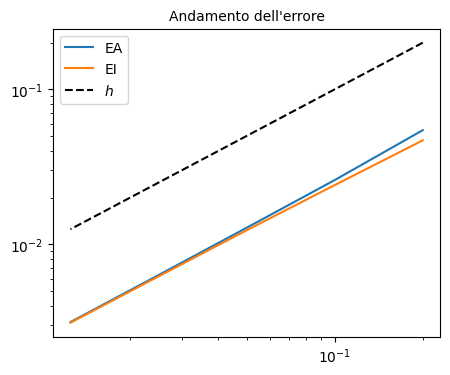

In [21]:
# Es. 3.5 - Ordini di convergenza
# passo h ed errori
hs, errEA, errEI = [], [], []

for k in range (5):
  # passo h
  hs.append(0.2/2**k)
  th, uh = eulero_avanti(f, t0, tN, y0, hs[-1])
  errEA.append(abs(yesatta(th)-uh).max())

  th, uh = eulero_indietro(f, t0, tN, y0, hs[-1])
  errEI.append(abs(yesatta(th)-uh).max())

plt.figure(figsize = (5, 4))
plt.loglog(hs, errEA, label = 'EA')
plt.loglog(hs, errEI, label = 'EI')
plt.loglog(hs, hs, '--k', label = '$h$')
plt.legend()
plt.title("Andamento dell'errore", fontsize = 10)
plt.show()

<mark>**Esercizio 3.6**</mark></br>
Risolvere il problema con i metodi di **Eulero in avanti** e di **Eulero all'indietro**, scegliendo un passo $h=1$. Riportare su grafici differenti le soluzioni numeriche ottenute, confrontandole con la soluzione esatta e calcolare gli errori ottenuti. Cosa si osserva?


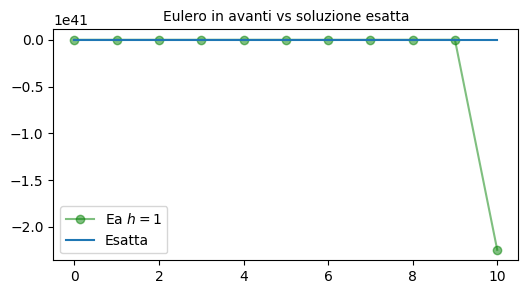

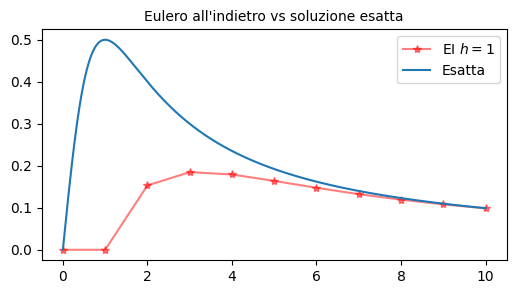

l'errore dell'Eulero in avanti è: 2.246814e+41 
l'errore dell'Eulero all'indietro è: 5.000000e-01 


In [22]:
# Eulero in avanti
tEA, uEA = eulero_avanti(f, t0, tN, y0, h = 1)

plt.figure(num=1, figsize = (6,3))
plt.plot(tEA, uEA, '-o', label = 'Ea $h=1$', alpha = 0.5, color = 'green')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero in avanti vs soluzione esatta", fontsize = 10)
plt.legend()

# Eulero all'indietro
tEI, uEI = eulero_indietro(f, t0, tN, y0, h = 1)

plt.figure(num=2, figsize = (6,3))
plt.plot(tEI, uEI, '-*', label = 'EI $h=1$', alpha = 0.5, color = 'red')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero all'indietro vs soluzione esatta", fontsize = 10)
plt.legend()
plt.show()


print("l'errore dell'Eulero in avanti è: %e " %max(abs(yesatta(tEA)-uEA)))
print("l'errore dell'Eulero all'indietro è: %e " %max(abs(yesatta(tEI)-uEI)))


Osservando i grafici della soluzione esatta e di quelle approssimate (ottenute con Eulero in avanti e all'indietro), così come gli errori, si nota come la scelta del passo $h$ sia fondamentale nel primo caso. Infatti, il metodo Eulero in avanti (esplicito) è condizionatamente assolutamente stabile, mentre il metodo Eulero all'indietro (implicito) è incondizionatamente assolutamente stabile.

# Esercizi per casa

<mark>**Esercizio 4**</mark></br>
In generale, il metodo di Eulero all'indietro è più oneroso (computazionalmente parlando) rispetto alla sua variante in avanti. In aggiunta, più $h$ è piccolo, e più la simulazione richiede tempo (bisogna fare più passi!). Per quantificare tutto ciò, provare a misurare il tempo d'esecuzione richiesto dai due metodi al variare di $h$.
</br>
</br>
*Hint: potete usare la funzione* $\texttt{perf\_counter}$ *del pacchetto* $\texttt{time}$ *per misurare i tempi d'esecuzione del calcolatore.*


In [23]:
from time import perf_counter
# passo h
hs, timeEA, timeEI =[], [], []
for k in range (5):
  hs.append(0.2/2**k)
  tEA_start=perf_counter()
  th, uh = eulero_avanti(f, t0, tN, y0, hs[-1])
  tEA_stop=perf_counter()

  timeEA.append(tEA_stop-tEA_start)

  tEI_start=perf_counter()
  th, uh = eulero_indietro(f, t0, tN, y0, hs[-1])
  tEI_stop=perf_counter()
  timeEI.append(tEI_stop-tEI_start)

print("time Eulero in avanti\t time Eulero all'indietro")
for i in range(5):
  print("   %e \t\t %e" %(timeEA[i], timeEI[i]))


time Eulero in avanti	 time Eulero all'indietro
   9.426600e-05 		 3.353150e-04
   8.240400e-05 		 4.948130e-04
   2.463890e-04 		 9.083730e-04
   3.421380e-04 		 2.279059e-03
   1.127121e-03 		 3.272682e-03


<mark>**Esercizio 5**</mark></br>
Un ulteriore metodo *implicito* ad un passo (*one-step*) è il metodo di Crank-Nicolson che possiede il seguente schema iterativo
</br></br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+\frac{h}{2}[f(t_{n},u_{n}) +f(t_{n+1},u_{n+1})] & n=0,\dots,N-1.
\end{cases}
\end{equation*}
</br>
A differenza dei metodi di Eulero in avanti e di Eulero all'indietro, che hanno convergenza lineare questo metodo ha un andamento quadratico.

Considerando sempre il problema di Cauchy
</br></br>
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0\le t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}
</br>

la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}

Calcolare gli errori </br>
\begin{equation*}
e_{h}=\max_{n=0,\dots,N}\;|y(t_{n})-u_{n}|,
\end{equation*}
al variare di $h=0.2, 0.1, 0.05, 0.025, 0.0125$ e rappresentarne l'andamento utilizzando un opportuno plot in scala logaritmica. I risultati sono coerenti con la teoria?

In [24]:
from utilis_ODE import crank_nicolson

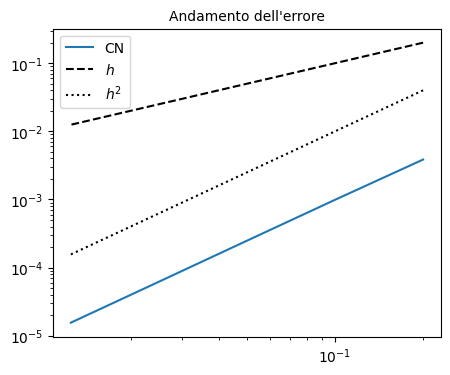

In [25]:
# Es. 5 - Ordine di convergenza Crank-Nicolson
# passo h ed errori
hs, hs2, errCN = [], [], []
t0, tN = 0, 10
f = lambda t, y: 1.0/(1+t**2) - 2*y*y
for k in range (5):
  hs.append(0.2/2**k)
  hs2.append((0.2/2**k)**2)
  th, uh = crank_nicolson(f, t0, tN, y0, hs[-1])
  errCN.append(abs(yesatta(th)-uh).max())

plt.figure(figsize = (5, 4))
plt.loglog(hs, errCN, label = 'CN')

plt.loglog(hs, hs, '--k', label = '$h$')
plt.loglog(hs, hs2, ':k', label = '$h^2$')
plt.legend()
plt.title("Andamento dell'errore", fontsize = 10)
plt.show()

<mark>**Esercizio 6**</mark></br>
Calcolare il massimo passo $h$ per il seguente problema di Cauchy
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=-3y(t) & 0\le t\le 1,\\ y(0)=1,
\end{cases}
\end{equation*}
la cui soluzione esatta è
\begin{equation*}
y(t)=e^{-3t}.
\end{equation*}
tale per cui il metodo di Eulero in avanti sia assolutemante stabile.

**Soluzione**

Dal momento che $\lambda\in \mathbb{R}^{-}$ e stiamo considerando un problema lineare (in $y$), il metodo di Eulero in avanti è condizionatamente assolutamente stabile se e solo se
\begin{equation*}
 |1+h\lambda| <1.
\end{equation*}

Abbiamo che $\lambda = -3$ e quindi richiediamo 
\begin{equation*}
h < \dfrac{2}{|\lambda|} = \dfrac{2}{3}.
\end{equation*}

**Commento nel caso in cui $f(t,y(t))$ non sia lineare (in $y$):**

Prendiamo il problema dell'esercizio $3$:

\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0< t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}

la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}

*Vogliamo stimare il massimo h per avere l'assoluta stabilità del metodo di Eulero in avanti.*

**Soluzione**
Per il caso generale del problema di Cauchy, assumiamo che esistano due costanti positive $\lambda_*$ e $\lambda^*$ con $\lambda_*<\lambda^*$, tali che 
\begin{equation*}
-\lambda^*  \le \dfrac{\partial f(t,y(t))}{\partial y} \le -\lambda_* \qquad \forall t \in I=[t_0, t_f].
\end{equation*}
Allora, un buon candidato per giocare il ruolo di $\lambda$ nell'analisi di stabilità sara $\lambda = -\lambda^*$.


\begin{equation*}
f(t,y(t)) = \frac{1}{1+t^2}-2y(t)^2 \qquad \rightarrow \qquad 
\dfrac{\partial f(t,y(t))}{\partial y} =  - 4 y(t) = -\frac{4t}{1+t^{2}}
\end{equation*}

Per comodità rappresentiamo il grafico della derivata

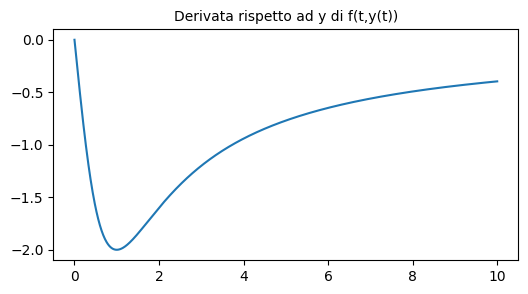

In [26]:
# Es. 3.1 - Plot soluzione esatta
# tempo iniziale e finale
t0, tN = 0, 10
# t per la rappresentazione grafica
tplot = np.linspace(t0, tN, 1000)
# soluzione esatta
yesatta = lambda t:-(4*t)/(1.0+t**2)

plt.figure(figsize = (6,3))
plt.plot(tplot, yesatta(tplot))
plt.title("Derivata rispetto ad y di f(t,y(t))", fontsize = 10)
plt.show()

Allora scelgo $\lambda^*=2$ e quindi basterà prendere $h < \dfrac{2}{|\lambda|} = 1$